In [7]:
# Import necessary libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create an SVM classifier
svm = SVC(kernel='linear')

# Train the classifier
svm.fit(X_train, y_train)

# Make predictions
y_pred = svm.predict(X_test)

# Evaluate the classifier
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [1]:
import cv2
import os
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from skimage.feature import hog
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
def load_images_folder_histogram(directory):
# 54.285714285714285 3
    data = []
    labels = []
    # Loading of all sub-folders in the directory
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)

    # Getting path of image files one-by-one from a sub-folder 'subdir_path'
        if os.path.isdir(subdir_path):
            for filename in os.listdir(subdir_path):
                filepath = os.path.join(subdir_path, filename)

                #Checking whether obtained path is a filepath
                if os.path.isfile(filepath):

                    # Load and preprocess image (resize to uniform size)
                    image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale using argument as cv2.IMREAD_GRAYSCALE

                    image = cv2.resize(image, (64, 64))  # Resize to 64x64 pixels

                    arr = image.flatten() #flattening the image of size 64x64 to make one-dimentional array
                    arr1 = np.histogram(arr,10) #Computation of histogram of the array with 256 bins
                    # arr1 = [np.average(arr), np.max(arr), np.median(arr)]  #Other features

                    # data.append(image.flatten())  # Flatten the image

                    #Assigning suitable tables to different classes
                    data.append(arr1[0])
                    if subdir == 'dogs':
                        labels.append(0)  # May use the folder name as the label
                    else:
                        labels.append(1)

    return np.array(data), np.array(labels)  #Convering results to Numpy arrays

In [3]:
# Path to the dataset
dataset_directory1 = r"C:/D folder/Programming/programs/my codes/ML codes/knn classifier/Dog-Cat Dataset/train"
dataset_directory2 = r"C:/D folder/Programming/programs/my codes/ML codes/knn classifier/Dog-Cat Dataset/test"

# Load images and labels
images_train, labels_train = load_images_folder_histogram(dataset_directory1)
images_test, labels_test = load_images_folder_histogram(dataset_directory2)

In [4]:
images_test.shape

(230, 10)

In [5]:
# Initialize and train the KNN classifier
acc=[]
for k in range(100):
    knn = KNeighborsClassifier(n_neighbors=k+1)  # Use 3 neighbors for KNN
    knn.fit(images_train, labels_train)

    # Predict on the test set
    y_pred = knn.predict(images_test)

    # Calculate accuracy
    accuracy = accuracy_score(labels_test, y_pred)
    acc.append(100*accuracy)
    #print(f"Classification Accuracy: {accuracy * 100:.2f}%")
print(np.max(acc), np.argmax(acc)+1)

70.43478260869566 41


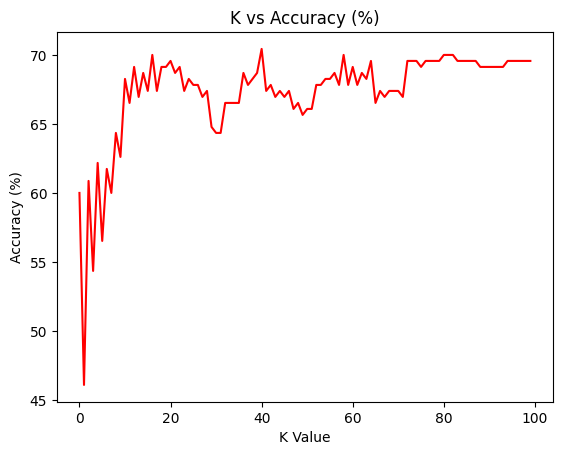

In [6]:
plt.plot(acc, 'red')
plt.xlabel("K Value")
plt.ylabel("Accuracy (%)")
plt.title("K vs Accuracy (%)")
plt.show()